In [1]:
from datetime import datetime, timedelta
import torch
from earth2studio.data import GEFS_FX, HRRR, GEFS_FX_721x1440
import os
import io
import tarfile
from pathlib import Path
import numpy as np
import requests
import tqdm


GEFS_SELECT_VARIABLES = [
    "u10m",
    "v10m",
    "t2m",
    "r2m",
    "sp",
    "msl",
    "tcwv",
]

GEFS_VARIABLES = [
    "u1000",
    "u925",
    "u850",
    "u700",
    "u500",
    "u250",
    "v1000",
    "v925",
    "v850",
    "v700",
    "v500",
    "v250",
    "z1000",
    "z925",
    "z850",
    "z700",
    "z500",
    "z200",
    "t1000",
    "t925",
    "t850",
    "t700",
    "t500",
    "t100",
    "r1000",
    "r925",
    "r850",
    "r700",
    "r500",
    "r100",
]

ds_gefs = GEFS_FX(cache=True)
ds_gefs_select = GEFS_FX_721x1440(cache=True, member="gec00")


def fetch_input_gefs(
    time: datetime, lead_time: timedelta, content_dtype: str = "float32"
):
    """Fetch input GEFS data and place into a single numpy array."""
    dtype = np.dtype(getattr(np, content_dtype))
    g = np.array(9.80665, dtype=dtype)  # standard gravity (m/s^2)

    # Fetch high-res select GEFS input data
    select_data = ds_gefs_select(time, lead_time, GEFS_SELECT_VARIABLES).values
    # Crop to bounding box [225, 21, 300, 53]
    select_data = select_data[:, 0, :, 148:277, 900:1201].astype(dtype)
    assert select_data.shape == (1, len(GEFS_SELECT_VARIABLES), 129, 301)

    # Fetch GEFS pressure-level input data
    pressure_data = ds_gefs(time, lead_time, GEFS_VARIABLES)

    # Interpolate to 0.25° grid (keeping your existing approach)
    pressure_data = torch.nn.functional.interpolate(
        torch.as_tensor(pressure_data.values),
        (len(GEFS_VARIABLES), 721, 1440),
        mode="nearest",
    ).numpy()

    # Crop to bounding box [225, 21, 300, 53]
    pressure_data = pressure_data[:, 0, :, 148:277, 900:1201].astype(dtype)
    assert pressure_data.shape == (1, len(GEFS_VARIABLES), 129, 301)

    # Divide all z-levels by g to convert geopotential (m^2/s^2) -> geopotential height (m)
    z_vars = {"z1000", "z925", "z850", "z700", "z500", "z200"}
    z_indices = [i for i, v in enumerate(GEFS_VARIABLES) if v in z_vars]
    pressure_data[:, z_indices, :, :] /= g

    # Create lead time field in 3-hour increments
    lead_hour = (int(lead_time.total_seconds() // (3 * 60 * 60)) * np.ones((1, 1, 129, 301), dtype=dtype))

    input_data = np.concatenate([select_data, pressure_data, lead_hour], axis=1)[None]
    return input_data

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter 


lats = np.load("corrdiff_output_lat.npy")
lons = np.load("corrdiff_output_lon.npy")

pc = ccrs.PlateCarree()

# Convert lons from 0-360° to -180 to 180°
lons = np.where(lons > 180, lons - 360, lons)

# Now use negative longitudes for Florida
la_lon = [-90.0, -80.0] 
la_lat = [25.0, 32.0]

central_lon = (la_lon[0] + la_lon[1]) / 2  # -85.0
central_lat = (la_lat[0] + la_lat[1]) / 2  # 28.5

projection2 = ccrs.LambertConformal(
    central_longitude=central_lon,
    central_latitude=central_lat,
    standard_parallels=(30, 60)  # or adjust for your region
)

# Create mask
mask = ((lons >= la_lon[0]) & (lons <= la_lon[1]) &
        (lats >= la_lat[0]) & (lats <= la_lat[1]))


In [3]:
def calculate_vorticity(u, v, lons, lats):
    """
    Calculate relative vorticity (vertical component of curl)
    on a latitude–longitude grid.

    Parameters:
    u, v : zonal and meridional wind components (m/s)
    lons, lats : 2D longitude and latitude grids (degrees)

    Returns:
    vorticity : s^-1
    """
    R = 6.371e6  # Earth radius (m)

    # Convert to radians
    lon = np.deg2rad(lons)
    lat = np.deg2rad(lats)

    # Grid spacing in radians
    dlon = np.gradient(lon, axis=1)
    dlat = np.gradient(lat, axis=0)

    # Compute terms
    coslat = np.cos(lat)

    dv_dlon = np.gradient(v, axis=1) / dlon
    ducos_dlat = np.gradient(u * coslat, axis=0) / dlat

    # Relative vorticity
    zeta = (dv_dlon - ducos_dlat) / (R * coslat)

    return zeta


In [4]:
year = 2024
month = 9
day = 26

# Loop through different H values

Lat = []
Lon = []

for H in [15, 18, 21, 24]:
    print(f"\n{'='*50}")
    print(f"Processing H = {H} hours")
    print(f"{'='*50}\n")
    
    time = datetime(year, month, day) # initial condition 
    lead_time1 = timedelta(hours = H) # model run time, note that corrdiff only allows 24hr prediction
    input_array = fetch_input_gefs(time, lead_time1)
    
    #ensure the dimension of input is correct 
    print(type(input_array), getattr(input_array, "shape", None), getattr(input_array, "dtype", None))
    np.save("corrdiff_inputs.npy", input_array)
    
    url = f"http://corrdiff-nim-service-laurahu:8000/v1/infer"
    files = {
        "input_array": ("input_array", open("corrdiff_inputs.npy", "rb")),
    }
    data = {
        "samples": 2, # users can choose how many samples they want to generate 
        "steps": 8, # users can also choose how many steps they want the diffusion mod to take 
        "seed": 0,
    }
    headers = {
        "accept": "application/x-tar",
    }
    
    print("Sending post request to NIM")
    r = requests.post(url, headers=headers, data=data, files=files, timeout=3000)
    if r.status_code != 200:
        raise Exception(r.content)
    else:
        # Dump response to file
        with open("output.tar", "wb") as tar:
            tar.write(r.content)
    print("Done!")
    
    
    u = []
    v = []
    
    with tarfile.open("output.tar") as tar:
        for i, member in enumerate(tar.getmembers()):
            arr_file = io.BytesIO()
            arr_file.write(tar.extractfile(member).read())
            arr_file.seek(0)
            data = np.load(arr_file)
            u10m = data[0, 0, 0]
            v10m = data[0, 0, 1]
            u.append(u10m)
            v.append(v10m)
            
    u = np.array(u)
    v = np.array(v)
    
    u10m = np.mean(u, axis = 0)
    v10m = np.mean(v, axis = 0)

    vorticity = calculate_vorticity(u10m, v10m, lons, lats)
    vorticity = gaussian_filter(vorticity, sigma=3)
    vorticity_masked = np.where(mask, vorticity, np.nan)
    
    # Use nanmax to ignore NaN values
    max_vort = np.nanmax(vorticity_masked)
    print("Maximum vorticity is:", max_vort)
    
    iy, ix = np.unravel_index(np.nanargmax(vorticity_masked), vorticity_masked.shape)
    max_lat = lats[iy, ix]
    max_lon = lons[iy, ix]
    print("Location:", max_lat, max_lon)
    
    Lat.append(max_lat)
    Lon.append(max_lon)

#======================================================================#

year = 2024
month = 9
day = 27

# Loop through different H values

for H in [3, 6]:
    print(f"\n{'='*50}")
    print(f"Processing H = {H} hours")
    print(f"{'='*50}\n")
    
    time = datetime(year, month, day) # initial condition 
    lead_time1 = timedelta(hours = H) # model run time, note that corrdiff only allows 24hr prediction
    input_array = fetch_input_gefs(time, lead_time1)
    
    #ensure the dimension of input is correct 
    print(type(input_array), getattr(input_array, "shape", None), getattr(input_array, "dtype", None))
    np.save("corrdiff_inputs.npy", input_array)
    
    url = f"http://corrdiff-nim-service-laurahu:8000/v1/infer"
    files = {
        "input_array": ("input_array", open("corrdiff_inputs.npy", "rb")),
    }
    data = {
        "samples": 2, # users can choose how many samples they want to generate 
        "steps": 8, # users can also choose how many steps they want the diffusion mod to take 
        "seed": 0,
    }
    headers = {
        "accept": "application/x-tar",
    }
    
    print("Sending post request to NIM")
    r = requests.post(url, headers=headers, data=data, files=files, timeout=3000)
    if r.status_code != 200:
        raise Exception(r.content)
    else:
        # Dump response to file
        with open("output.tar", "wb") as tar:
            tar.write(r.content)
    print("Done!")
    
    
    # global mean and standard deviati
    
    u = []
    v = []
    
    with tarfile.open("output.tar") as tar:
        for i, member in enumerate(tar.getmembers()):
            arr_file = io.BytesIO()
            arr_file.write(tar.extractfile(member).read())
            arr_file.seek(0)
            data = np.load(arr_file)
            u10m = data[0, 0, 0]
            v10m = data[0, 0, 1]
            u.append(u10m)
            v.append(v10m)
            
    u = np.array(u)
    v = np.array(v)
    
    u10m = np.mean(u, axis = 0)
    v10m = np.mean(v, axis = 0)

    vorticity = calculate_vorticity(u10m, v10m, lons, lats)
    vorticity = gaussian_filter(vorticity, sigma=3)
    vorticity_masked = np.where(mask, vorticity, np.nan)
    
    # Use nanmax to ignore NaN values
    max_vort = np.nanmax(vorticity_masked)
    print("Maximum vorticity is:", max_vort)
    iy, ix = np.unravel_index(np.nanargmax(vorticity_masked), vorticity_masked.shape)
    max_lat = lats[iy, ix]
    max_lon = lons[iy, ix]
    print("Location:", max_lat, max_lon)
    
    Lat.append(max_lat)
    Lon.append(max_lon)
    
    


Processing H = 15 hours



Fetching GEFS data:   0%|          | 0/7 [00:00<?, ?it/s]

2026-04-06 00:16:43.649 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240926/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f015 7658171-822028


Fetching GEFS data: 100%|██████████| 7/7 [00:00<00:00,  9.55it/s]


2026-04-06 00:16:44.225 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240926/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f015 6815180-842991
2026-04-06 00:16:44.252 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240926/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f015 1776739-741652
2026-04-06 00:16:44.277 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240926/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f015 3783397-432255
2026-04-06 00:16:44.302 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240926/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f015 11789709-456499
2026-04-06 00:16:44.330 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240926/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f015 4652182-669248
2026-04-06 00:16:44.356 | DEBUG   

...

2026-04-06 00:24:07.445 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240927/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f006 9458125-137747
2026-04-06 00:24:07.461 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240927/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f006 6341458-263713
2026-04-06 00:24:07.473 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240927/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f006 5848841-234297
2026-04-06 00:24:07.587 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240927/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f006 7722425-253006


Fetching GEFS data:   0%|          | 0/30 [00:01<?, ?it/s]

2026-04-06 00:24:07.680 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240927/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f006 1922846-112770
2026-04-06 00:24:07.791 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240927/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f006 10975327-262194
2026-04-06 00:24:07.803 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240927/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f006 2035616-142669
2026-04-06 00:24:07.865 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240927/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f006 2673312-207477
2026-04-06 00:24:07.879 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240927/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f006 10712100-263227


Fetching GEFS data: 100%|██████████| 30/30 [00:01<00:00, 25.87it/s]


2026-04-06 00:24:07.892 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240927/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f006 8666203-262279
2026-04-06 00:24:07.905 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20240927/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f006 6605171-244657
<class 'numpy.ndarray'> (1, 1, 38, 129, 301) float32
Sending post request to NIM
Done!
Maximum vorticity is: 0.0010252761866362124
Location: 31.23384815879628 -83.71037676559286


In [5]:
import pandas as pd

Total_track = pd.read_csv('/home/jovyan/earth2studio-project/corrdiff-project/ibtracs.last3years.list.v04r01.csv', 
                        header = None)

Helene_track = Total_track[(Total_track[5] == 'HELENE') & (Total_track[6] >= '2024-09-26 15:00:00') & (Total_track[6] <= '2024-09-27 06:00:00')] 


Helene_track = Helene_track.drop(index=[10096, 10097]).reset_index(drop=True)

Helene_track_lon = np.array(Helene_track[9])
Helene_track_lat = np.array(Helene_track[8])


Lon = np.array(Lon)
Lat = np.array(Lat)




/tmp/ipykernel_372/2680378393.py:3: DtypeWarning: Columns (1,2,8,9,14,19,20,25,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  Total_track = pd.read_csv('/home/jovyan/earth2studio-project/corrdiff-project/ibtracs.last3years.list.v04r01.csv',


In [6]:
from datetime import datetime, timedelta
from earth2studio.data import HRRR_FX

# Initialize the forecast data source
ds = HRRR_FX(source="aws")

# Model run time (when HRRR was initialized)
init_time = datetime(2024, 9, 26, 0, 0, 0)  # 00Z run


lead_times = [timedelta(hours=h) for h in [15, 18, 21, 24, 27, 30]]

# Variables you want
variables = ["t2m", "u10m", "v10m", "mslp"]

# Fetch the forecast
data = ds(time=init_time, lead_time=lead_times, variable=variables)




Fetching HRRR data:   0%|          | 0/24 [00:00<?, ?it/s]

2026-04-06 00:40:43.159 | DEBUG    | earth2studio.data.hrrr:fetch_array:501 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240926/conus/hrrr.t00z.wrfsfcf18.grib2 54378675-2381615


Fetching HRRR data:   0%|          | 0/24 [00:00<?, ?it/s]

2026-04-06 00:40:43.644 | DEBUG    | earth2studio.data.hrrr:fetch_array:501 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240926/conus/hrrr.t00z.wrfsfcf30.grib2 56887762-2381615
2026-04-06 00:40:43.705 | DEBUG    | earth2studio.data.hrrr:fetch_array:501 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240926/conus/hrrr.t00z.wrfsfcf21.grib2 47347455-1237192
2026-04-06 00:40:43.817 | DEBUG    | earth2studio.data.hrrr:fetch_array:501 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240926/conus/hrrr.t00z.wrfsfcf15.grib2 57766367-2381615


Fetching HRRR data:   0%|          | 0/24 [00:00<?, ?it/s]

...

2026-04-06 00:40:44.909 | DEBUG    | earth2studio.data.hrrr:fetch_array:501 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240926/conus/hrrr.t00z.wrfsfcf24.grib2 47127965-1226353
2026-04-06 00:40:44.982 | DEBUG    | earth2studio.data.hrrr:fetch_array:501 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240926/conus/hrrr.t00z.wrfsfcf27.grib2 56748839-2381615


Fetching HRRR data:   0%|          | 0/24 [00:02<?, ?it/s]

2026-04-06 00:40:45.115 | DEBUG    | earth2studio.data.hrrr:fetch_array:501 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240926/conus/hrrr.t00z.wrfsfcf24.grib2 56501448-2381615
2026-04-06 00:40:45.163 | DEBUG    | earth2studio.data.hrrr:fetch_array:501 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240926/conus/hrrr.t00z.wrfsfcf24.grib2 29462842-618607
2026-04-06 00:40:45.227 | DEBUG    | earth2studio.data.hrrr:fetch_array:501 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240926/conus/hrrr.t00z.wrfsfcf24.grib2 54119833-2381615
2026-04-06 00:40:45.284 | DEBUG    | earth2studio.data.hrrr:fetch_array:501 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240926/conus/hrrr.t00z.wrfsfcf30.grib2 29333733-599550


Fetching HRRR data: 100%|██████████| 24/24 [00:02<00:00, 10.45it/s]

2026-04-06 00:40:45.332 | DEBUG    | earth2studio.data.hrrr:fetch_array:501 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240926/conus/hrrr.t00z.wrfsfcf18.grib2 29199611-626692
2026-04-06 00:40:45.386 | DEBUG    | earth2studio.data.hrrr:fetch_array:501 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240926/conus/hrrr.t00z.wrfsfcf15.grib2 55384752-2381615


Minimum mslp: <xarray.DataArray ()> Size: 8B
array(97733.)
Coordinates:
    time       datetime64[ns] 8B 2024-09-26
    lead_time  timedelta64[ns] 8B 18:00:00
    variable   <U4 16B 'mslp' Pa
Minimum pressure location: 26.74°N, -85.00°W


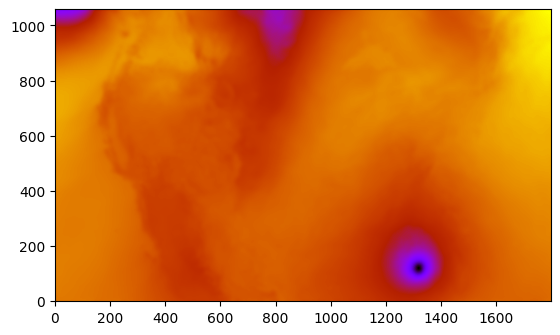

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

hrrr_lon = []
hrrr_lat = []
mask = ((lons >= la_lon[0]) & (lons <= la_lon[1]) &
        (lats >= la_lat[0]) & (lats <= la_lat[1]))

# Extract data
fig, ax = plt.subplots()
pressure_data = data[0, 1, 3, :, :]
windspeed = np.sqrt(data[0, 1, 1, :, :]**2 + data[0, 1, 2, :, :]**2)
ax.imshow(pressure_data, cmap="gnuplot", origin = 'lower')

#Apply mask so we get minimal pressure 
# Find minimum pressure
min_mslp = np.min(pressure_data)
print("Minimum mslp:", min_mslp, "Pa")

# Find the INDEX where minimum occurs
min_idx = np.unravel_index(pressure_data.argmin(), pressure_data.shape)

# Get lat/lon at that location
min_lat = lats[min_idx]
min_lon = lons[min_idx]

print(f"Minimum pressure location: {min_lat:.2f}°N, {min_lon:.2f}°W")
lon_hrrr = []
lat_hrrr = []

for i in range(6):
    pressure_data = data[0, i, 3, :, :]
    min_mslp = np.min(pressure_data)
    min_idx = np.unravel_index(pressure_data.argmin(), pressure_data.shape)
    lat_hrrr.append(lats[min_idx])
    lon_hrrr.append(lons[min_idx])

lon_hrrr = np.array(lon_hrrr)
lat_hrrr = np.array(lat_hrrr)


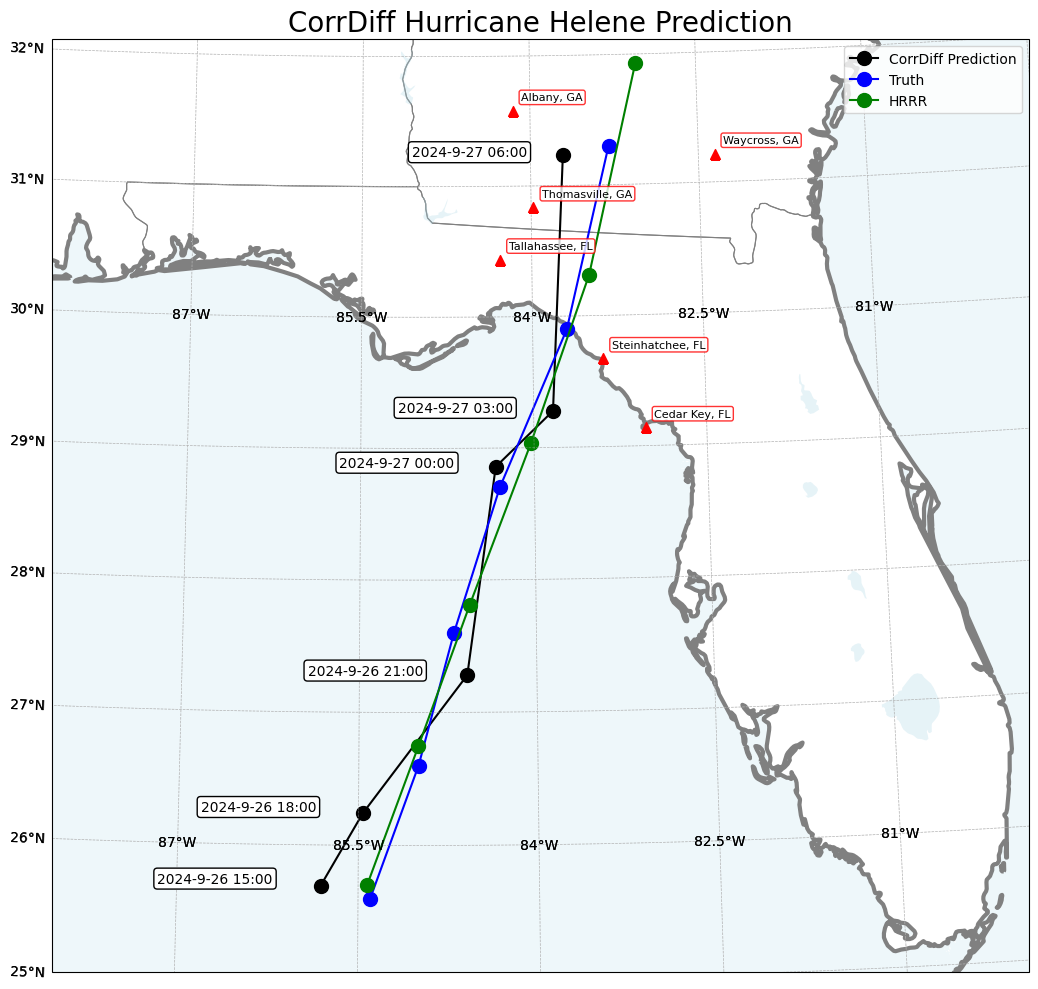

In [8]:

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(1, 1, 1, projection=projection2)
 

# Make sure to plot AFTER setting up the map, and use transform
ax.coastlines(linewidth=3, color='gray')
ax.add_feature(cfeature.STATES, linewidth=0.8, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=1.5, edgecolor='darkgray')
ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor='lightblue')
ax.add_feature(cfeature.OCEAN, alpha=0.2, facecolor='lightblue')

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False


# Plot the point with proper transform
ax.plot(Lon, Lat, 'o-', color='black', markersize=10, 
        transform=ccrs.PlateCarree(), label = 'CorrDiff Prediction')
ax.plot(Helene_track_lon, Helene_track_lat, 'o-', color = 'blue', markersize = 10,
                transform=ccrs.PlateCarree(), label = 'Truth')
ax.plot(lon_hrrr, lat_hrrr, 'o-', color = 'green', markersize = 10,
                transform=ccrs.PlateCarree(), label = 'HRRR')



Time_Stamps = ['2024-9-26 15:00', '2024-9-26 18:00', '2024-9-26 21:00', '2024-9-27 00:00', '2024-9-27 03:00', '2024-9-27 06:00']
count = 0
for i in Time_Stamps:
    ax.text(Lon[count] - 1.35,
            Lat[count] ,
            i,
            transform=ccrs.PlateCarree(),
            fontsize = 10,
            bbox = dict(boxstyle = "round,pad = 0.25",
                       facecolor = "white",
                       edgecolor = "black"))
    count += 1

cities = {
    "Cedar Key, FL": (29.1383, -83.0316),
    "Steinhatchee, FL": (29.6716, -83.3876),
    "Tallahassee, FL": (30.4383, -84.2807),
    "Albany, GA": (31.5785, -84.1557),
    "Thomasville, GA": (30.8366, -83.9788),
    "Waycross, GA": (31.2136, -82.3540)

}

for name, (lat, lon) in cities.items():
    # plot city marker
    ax.scatter(lon, lat,
               s=50, marker='^',
               color='red',
               transform=ccrs.PlateCarree(),
               zorder=8)

    # add city label with box
    ax.text(lon + 0.08, lat + 0.08, name,
            fontsize=8,
            transform=ccrs.PlateCarree(),
            zorder=9,
            bbox=dict(boxstyle="round,pad=0.2",
                      facecolor="white",
                      edgecolor="red",
                      alpha=0.8))
  
ax.set_extent([la_lon[0] + 2, la_lon[1], la_lat[0], la_lat[1]], crs=pc)
ax.set_title('CorrDiff Hurricane Helene Prediction', fontsize = 20)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.legend()
plt.tight_layout()
plt.savefig('HurrHele_Prediction_track.png') 
plt.show()

[-85.8093406  -85.4646206  -84.58836941 -84.33344291 -83.83178467
 -83.71037677]
[-85.4 -85.0 -84.7 -84.3 -83.7 -83.3]
[25.69515034 26.23995255 27.28078287 28.85791816 29.27799375 31.23384816]
[25.6 26.6 27.6 28.7 29.9 31.3]


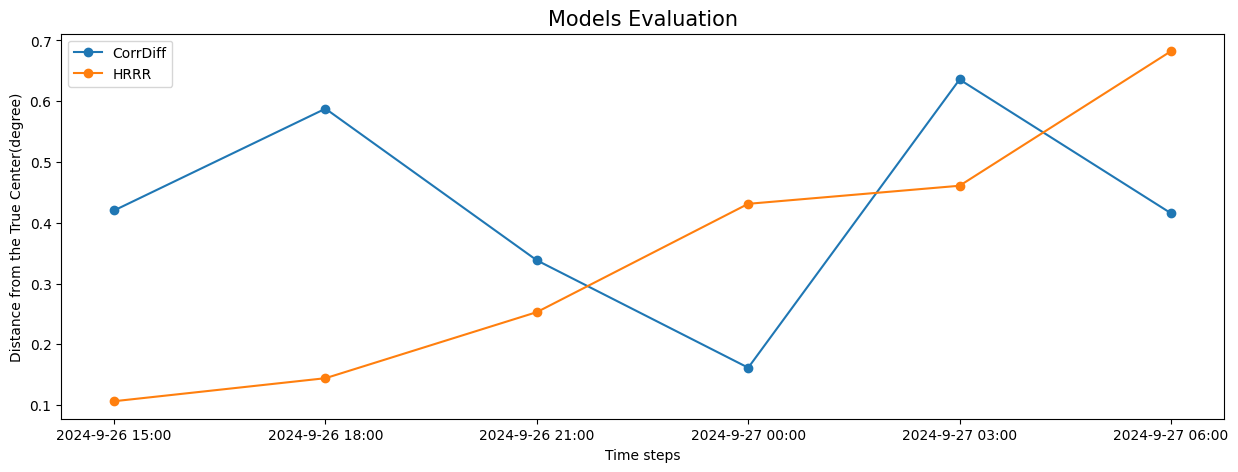

In [9]:

print(Lon)
print(Helene_track_lon)
print(Lat)
print(Helene_track_lat)

d = []
d2 = []

for i in range(len(Lon)):
    distance1 = np.sqrt((Lon[i] - Helene_track_lon[i])**2 + (Lat[i] - Helene_track_lat[i])**2)
    d.append(distance1)
    distance2 = np.sqrt((lon_hrrr[i] - Helene_track_lon[i])**2 + (lat_hrrr[i] - Helene_track_lat[i])**2)
    d2.append(distance2)

plt.figure(figsize = (15, 5))
Time_Stamps = ['2024-9-26 15:00', '2024-9-26 18:00', '2024-9-26 21:00', '2024-9-27 00:00', '2024-9-27 03:00', '2024-9-27 06:00']
plt.plot(Time_Stamps, d, marker = 'o', label = 'CorrDiff')
plt.plot(Time_Stamps, d2, marker = 'o', label = 'HRRR')
plt.xlabel('Time steps')
plt.ylabel('Distance from the True Center(degree)')
plt.title('Models Evaluation', fontsize = 15)
plt.legend()
plt.savefig('ModelEval.png',dpi = 300)



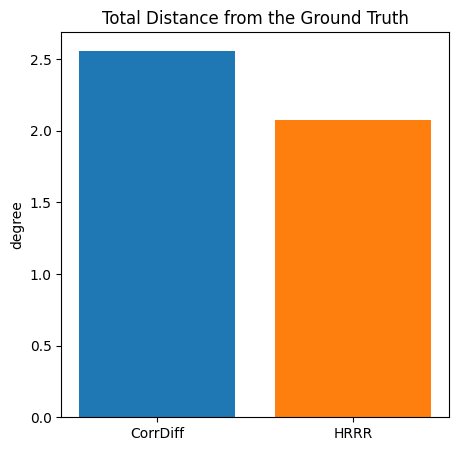

In [22]:
plt.figure(figsize = (5, 5))
plt.title('Total Distance from the Ground Truth')
plt.ylabel('degree')
plt.bar('CorrDiff', np.sum(d))
plt.bar('HRRR', np.sum(d2))

plt.savefig('TotalDis.png', dpi = 300)